IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LOAD DATASET

In [2]:
df = pd.read_csv("C:/Users/dhuba/OneDrive/ds/indian_railway_dataset.csv")


DATA INSPECTION

In [3]:
print(df.shape)
df.head()


(417080, 34)


,schedule_arrival,schedule_day,schedule_train_name,schedule_station_name,station_code,schedule_id,train_number,schedule_departure,third_ac,arrival,...,duration_h,train_type,first_ac,distance,station_state,station_name,station_zone,station_address,longitude,latitude
0,NaN,1.0,Falaknuma Lingampalli MMTS,KACHEGUDA FALAKNUMA,FM,302214,47154,07:55:00,0,09:15:00,...,1.0,Hyd,0,37.0,NaN,KACHEGUDA FALAKNUMA,NaN,NaN,78.474481,17.332197
1,NaN,1.0,Thrissur Guruvayur Passenger,THRISUR,TCR,281458,56044,18:55:00,0,19:30:00,...,0.0,Pass,0,23.0,NaN,THRISUR,NaN,NaN,76.207919,10.514790
2,NaN,1.0,Porbandar Muzaffarpur Express,PORBANDAR,PBR,309335,19269,15:05:00,1,18:10:00,...,51.0,Exp,0,2470.0,Gujarat,PORBANDAR,WR,"Porbandar, Gujarat",69.615506,21.643598
3,NaN,1.0,RAIPUR ITWARI PASS,RAIPUR JN,R,283774,58205,13:30:00,0,21:20:00,...,7.0,Pass,0,298.0,NaN,RAIPUR JN,NaN,NaN,81.629328,21.256462
4,NaN,1.0,Gomoh-Asansol MEMU,GOMOH JN,GMO,319937,63542,07:20:00,0,09:20:00,...,2.0,MEMU,0,87.0,NaN,GOMOH JN,NaN,NaN,86.148230,23.873106


Information about dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417080 entries, 0 to 417079
Data columns (total 34 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   schedule_arrival       389245 non-null  object 
 1   schedule_day           394519 non-null  float64
 2   schedule_train_name    417072 non-null  object 
 3   schedule_station_name  417078 non-null  object 
 4   station_code           417080 non-null  object 
 5   schedule_id            417080 non-null  int64  
 6   train_number           417080 non-null  object 
 7   schedule_departure     389253 non-null  object 
 8   third_ac               417080 non-null  int64  
 9   arrival                415269 non-null  object 
 10  from_station_code      417080 non-null  object 
 11  train_name             417072 non-null  object 
 12  train_zone             415269 non-null  object 
 13  chair_car              417080 non-null  int64  
 14  first_class            417080 non-nu

COLUMN NAMES

In [5]:
print(df.columns.tolist())

['schedule_arrival', 'schedule_day', 'schedule_train_name', 'schedule_station_name', 'station_code', 'schedule_id', 'train_number', 'schedule_departure', 'third_ac', 'arrival', 'from_station_code', 'train_name', 'train_zone', 'chair_car', 'first_class', 'duration_m', 'sleeper', 'from_station_name', 'departure', 'return_train', 'to_station_code', 'second_ac', 'classes', 'to_station_name', 'duration_h', 'train_type', 'first_ac', 'distance', 'station_state', 'station_name', 'station_zone', 'station_address', 'longitude', 'latitude']


KEEP ONLY REQUIRED COLUMNS

In [ ]:
keep_columns = [
    'train_number',
    'train_name',
    'train_zone',s
    'train_type',
    'from_station_name',
    'to_station_name',
    'station_name',
    'station_state',
    'arrival',
    'departure',
    'arrival_hour',
    'departure_hour',
    'schedule_day',
    'distance',
    'duration_h',
    'duration_m',
    'longitude', 'latitude','first_ac','second_ac','third_ac','sleeper'
]
keep_columns = [col for col in keep_columns if col in df.columns]
df = df[keep_columns]
print("Shape After Removing Unwanted Columns:", df.shape)
df.head()

Shape After Removing Unwanted Columns: (417080, 16)


,train_number,train_name,train_zone,train_type,from_station_name,to_station_name,station_name,station_state,arrival,departure,schedule_day,distance,duration_h,duration_m,second_ac,sleeper
0,47154,Falaknuma Lingampalli MMTS,SCR,Hyd,KACHEGUDA FALAKNUMA,LINGAMPALLI,KACHEGUDA FALAKNUMA,NaN,09:15:00,07:55:00,1.0,37.0,1.0,20.0,0,0
1,56044,Thrissur Guruvayur Passenger,SR,Pass,THRISUR,GURUVAYUR,THRISUR,NaN,19:30:00,18:55:00,1.0,23.0,0.0,35.0,0,0
2,19269,Porbandar Muzaffarpur Express,WR,Exp,PORBANDAR,MUZAFFARPUR JN,PORBANDAR,Gujarat,18:10:00,15:05:00,1.0,2470.0,51.0,5.0,1,1
3,58205,RAIPUR ITWARI PASS,SECR,Pass,RAIPUR JN,ITWARI,RAIPUR JN,NaN,21:20:00,13:30:00,1.0,298.0,7.0,50.0,0,0
4,63542,Gomoh-Asansol MEMU,ER,MEMU,GOMOH JN,ASANSOL JN,GOMOH JN,NaN,09:20:00,07:20:00,1.0,87.0,2.0,0.0,0,0


REMOVING DUPLICATE ROWS

In [7]:
print("Duplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates Removed!")
print("Current Shape:", df.shape)

Duplicate Rows: 1504
Duplicates Removed!
Current Shape: (415576, 16)


CHECK MISSING VALUES

In [8]:
print("Missing Values in Each Column:\n")
print(df.isnull().sum())

Missing Values in Each Column:

train_number              0
train_name                8
train_zone             1807
train_type             1807
from_station_name         0
to_station_name           0
station_name              2
station_state        300928
arrival                1807
departure              1807
schedule_day          22261
distance               1807
duration_h             1807
duration_m             1807
second_ac                 0
sleeper                   0
dtype: int64


DATA CLEANING

In [9]:
# Numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())
# Categorical columns
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
train_number         0
train_name           0
train_zone           0
train_type           0
from_station_name    0
to_station_name      0
station_name         0
station_state        0
arrival              0
departure            0
schedule_day         0
distance             0
duration_h           0
duration_m           0
second_ac            0
sleeper              0
dtype: int64


CLEANED DATASET INFORMATION

In [10]:
print("Final Shape:", df.shape)
df.info()

Final Shape: (415576, 16)
<class 'pandas.core.frame.DataFrame'>
Index: 415576 entries, 0 to 417079
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   train_number       415576 non-null  object 
 1   train_name         415576 non-null  object 
 2   train_zone         415576 non-null  object 
 3   train_type         415576 non-null  object 
 4   from_station_name  415576 non-null  object 
 5   to_station_name    415576 non-null  object 
 6   station_name       415576 non-null  object 
 7   station_state      415576 non-null  object 
 8   arrival            415576 non-null  object 
 9   departure          415576 non-null  object 
 10  schedule_day       415576 non-null  float64
 11  distance           415576 non-null  float64
 12  duration_h         415576 non-null  float64
 13  duration_m         415576 non-null  float64
 14  second_ac          415576 non-null  int64  
 15  sleeper            415576 non-

In [11]:
print(df['arrival'].dtype)
print(df['departure'].dtype)

object
object


EDA

In [12]:
df["train_zone"] = df["train_zone"].replace("?", "Unknown")

In [13]:
df["distance"] = pd.to_numeric(df["distance"], errors="coerce")

In [14]:
print("Average Distance:", np.mean(df["distance"]))
print("Maximum Distance:", np.max(df["distance"]))
print("Minimum Distance:", np.min(df["distance"]))
print("Standard Deviation:", np.std(df["distance"]))

Average Distance: 1401.966853235028
Maximum Distance: 4279.0
Minimum Distance: 0.0
Standard Deviation: 932.260885855021


In [15]:
print("Unique Trains:", df['train_number'].nunique())

Unique Trains: 5208


In [16]:
print("Unique Stations:", df['station_name'].nunique())

Unique Stations: 8494


VISUALIZATIONS

1.Top 5 Busiest Stations

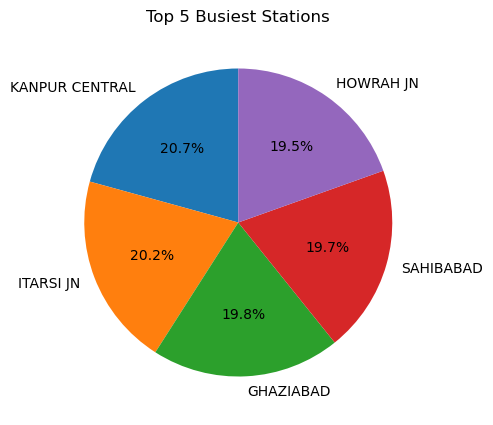

In [17]:
top5_stations = df['station_name'].value_counts().head(5)
plt.figure(figsize=(5,5))
plt.pie(
    top5_stations,
    labels=top5_stations.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Top 5 Busiest Stations')
plt.show()

2.Top 10 Trains with Most Stops

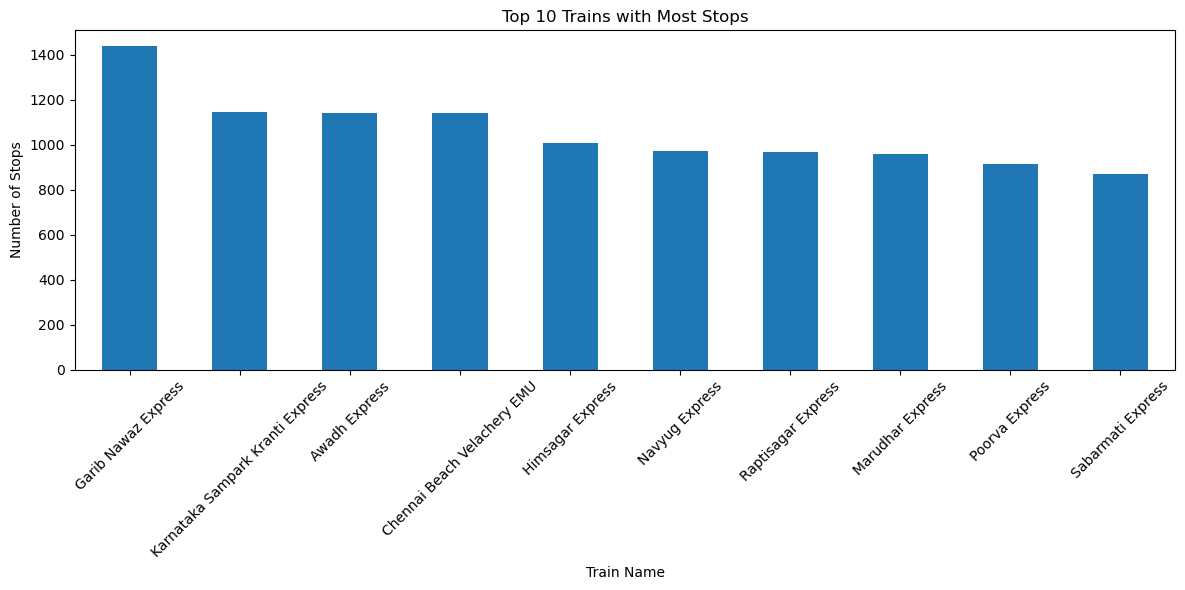

In [18]:
train_stops = df.groupby('train_name')['station_name'].count()
train_stops = train_stops.sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
train_stops.plot(kind='bar')
plt.title('Top 10 Trains with Most Stops')
plt.xlabel('Train Name')
plt.ylabel('Number of Stops')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

3.Arrival Hours Distribution

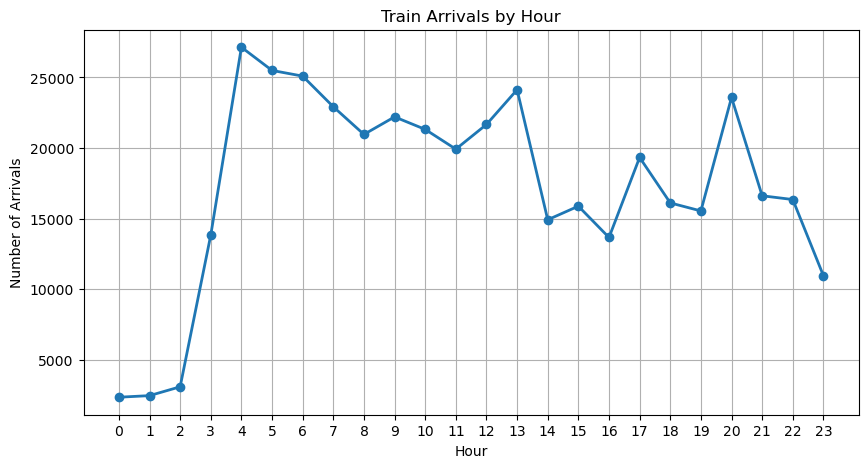

In [19]:
arrival_hours = pd.to_datetime(
    df['arrival'],
    format='%H:%M:%S',
    errors='coerce'
).dt.hour
arrival_counts = arrival_hours.value_counts().sort_index()
plt.figure(figsize=(10,5))
plt.plot(
    arrival_counts.index,
    arrival_counts.values,
    marker='o',
    linewidth=2
)
plt.title('Train Arrivals by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Arrivals')
plt.xticks(range(24))
plt.grid(True)
plt.show()

4. Departure Peak Hours

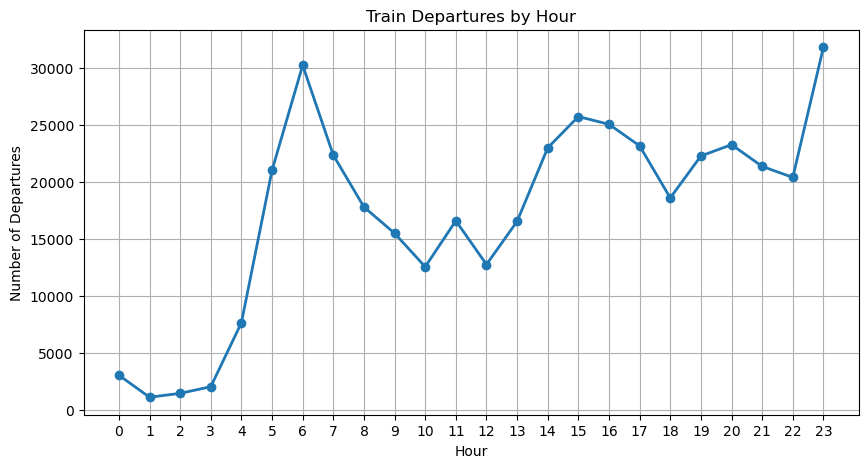

In [20]:
departure_hours = pd.to_datetime(
    df['departure'],
    format='%H:%M:%S',
    errors='coerce'
).dt.hour
departure_counts = departure_hours.value_counts().sort_index()
plt.figure(figsize=(10,5))
plt.plot(
    departure_counts.index,
    departure_counts.values,
    marker='o',
    linewidth=2
)
plt.title('Train Departures by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Departures')
plt.xticks(range(24))
plt.grid(True)
plt.show()

5.Station stop frequency

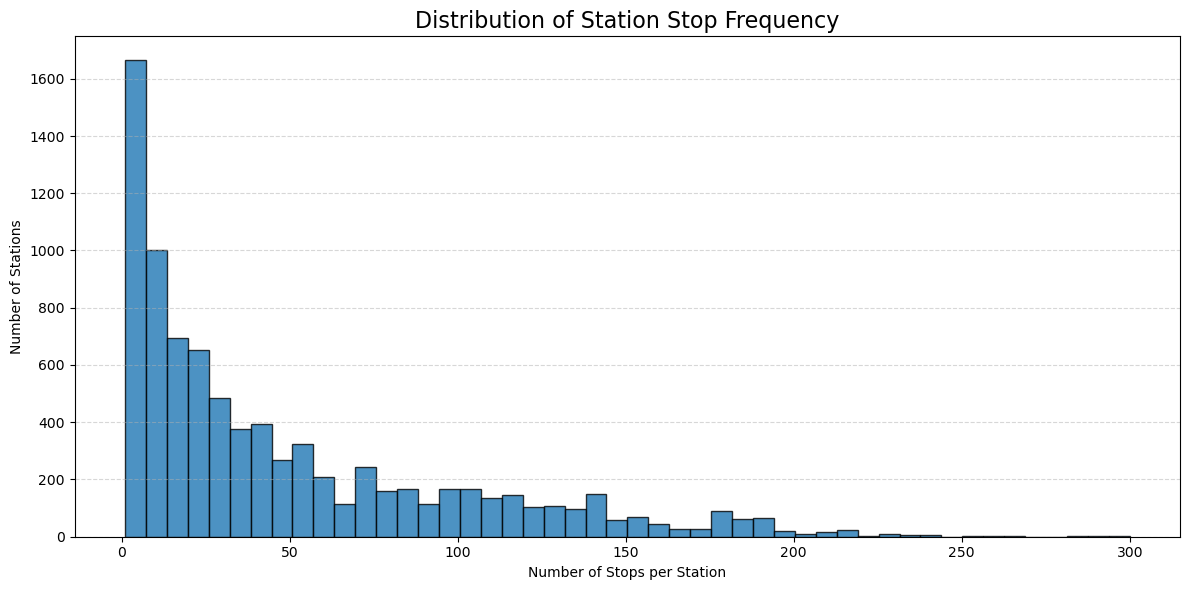

In [21]:
station_frequency = df.groupby('station_name').size()
plt.figure(figsize=(12,6))
plt.hist(
    station_frequency,
    bins='auto',
    edgecolor='black',
    alpha=0.8
)
plt.title('Distribution of Station Stop Frequency', fontsize=16)
plt.xlabel('Number of Stops per Station')
plt.ylabel('Number of Stations')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

6. Day-wise Train Movement

schedule_day
1.0     183171
2.0     196837
3.0      32810
4.0       2589
5.0        124
6.0          4
7.0          6
8.0          5
9.0          5
10.0        14
11.0         5
12.0         5
13.0         1
Name: count, dtype: int64


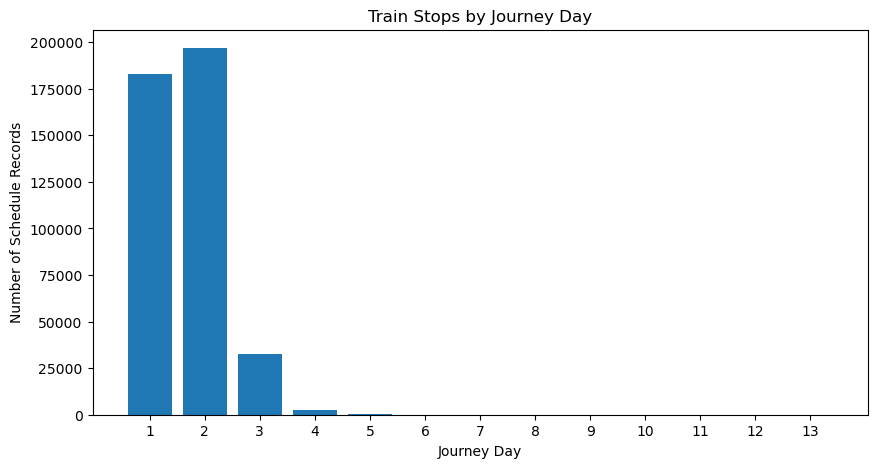

In [22]:
day_data = pd.to_numeric(df['schedule_day'], errors='coerce')
day_count = day_data.value_counts().sort_index()
print(day_count)
plt.figure(figsize=(10,5))
plt.bar(day_count.index, day_count.values)
plt.title('Train Stops by Journey Day')
plt.xlabel('Journey Day')
plt.ylabel('Number of Schedule Records')
plt.xticks(day_count.index)
plt.show()

7. Distance Analysis

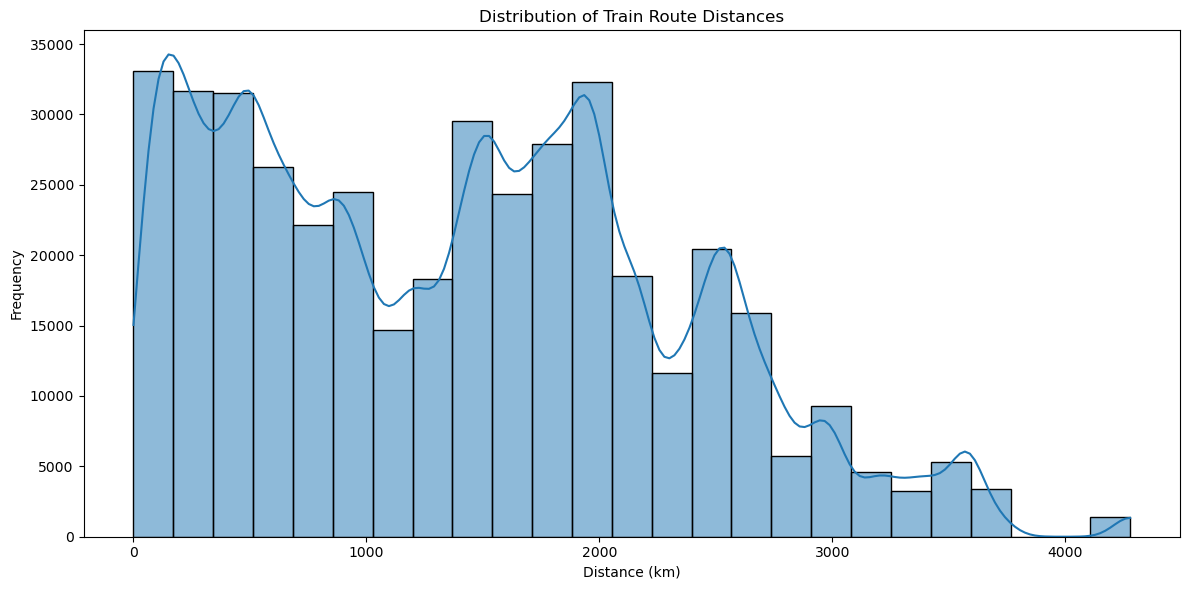

In [23]:
df['distance'] = pd.to_numeric(df['distance'], errors='coerce')
plt.figure(figsize=(12,6))
sns.histplot(
    df['distance'].dropna(),
    bins=25,
    kde=True
)
plt.title('Distribution of Train Route Distances')
plt.xlabel('Distance (km)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

8.Top 10 longest train

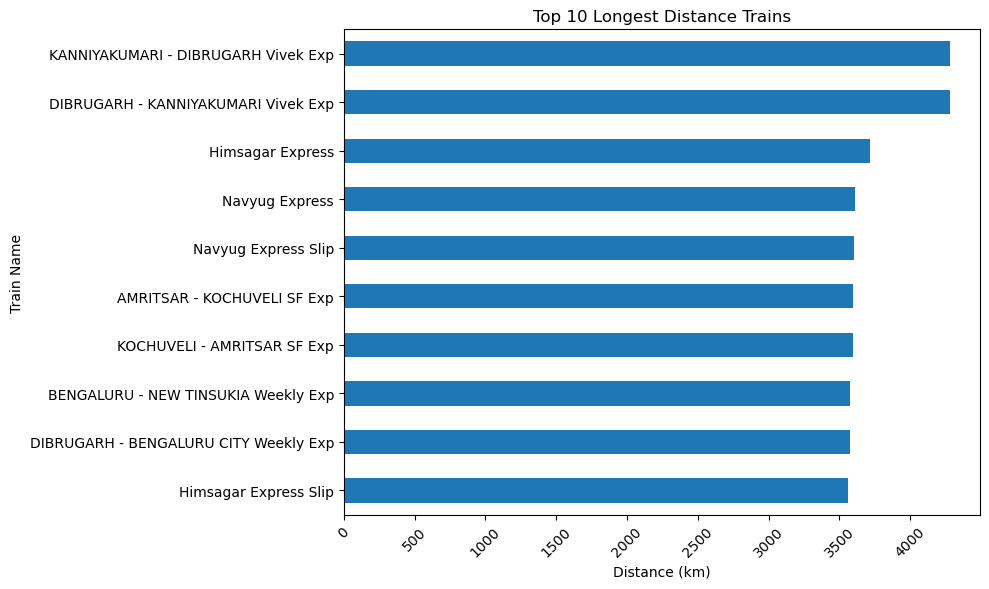

In [24]:
longest_trains = df.groupby('train_name')['distance'].max()
longest_trains = longest_trains.sort_values(
    ascending=False
).head(10)
plt.figure(figsize=(10,6))
longest_trains.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 10 Longest Distance Trains')
plt.xlabel('Distance (km)')
plt.ylabel('Train Name')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

10. Heatmap of Train Activity by Hour

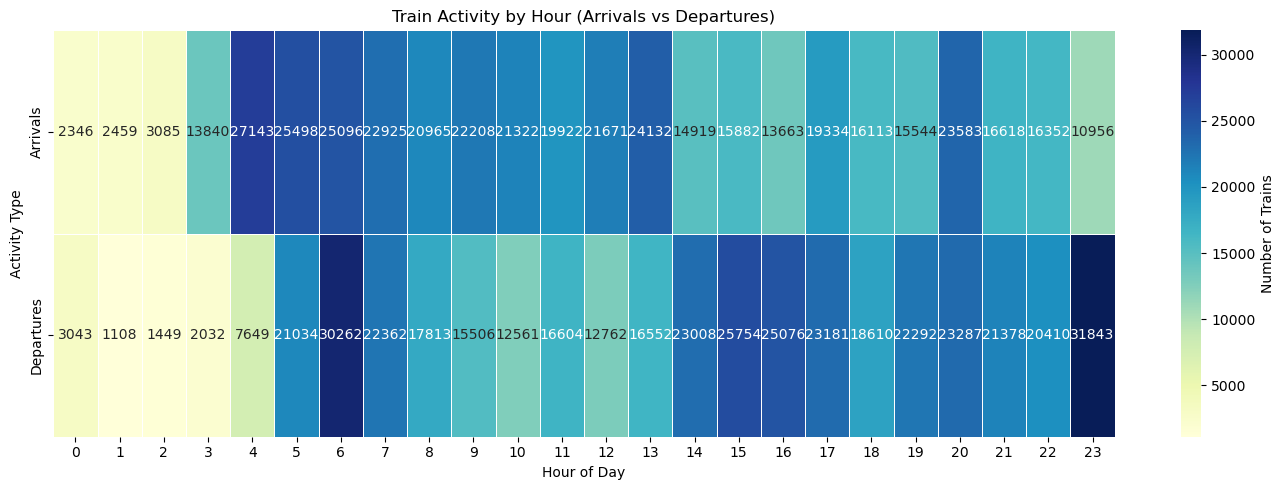

In [25]:
# Extract arrival hour
arrival_hours = pd.to_datetime(
    df['arrival'],
    format='%H:%M:%S',
    errors='coerce'
).dt.hour
# Extract departure hour
departure_hours = pd.to_datetime(
    df['departure'],
    format='%H:%M:%S',
    errors='coerce'
).dt.hour
# Count trains per hour
arrival_counts = arrival_hours.value_counts().sort_index()
departure_counts = departure_hours.value_counts().sort_index()
# Create heatmap data
heatmap_data = pd.DataFrame({
    'Arrivals': arrival_counts,
    'Departures': departure_counts
}).fillna(0)
# Transpose the data
heatmap_landscape = heatmap_data.T
plt.figure(figsize=(14, 5))
sns.heatmap(
    heatmap_landscape,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Number of Trains'}
)
plt.title('Train Activity by Hour (Arrivals vs Departures)')
plt.xlabel('Hour of Day')
plt.ylabel('Activity Type')
plt.tight_layout()
plt.show()

In [26]:
print(df.columns.tolist())

['train_number', 'train_name', 'train_zone', 'train_type', 'from_station_name', 'to_station_name', 'station_name', 'station_state', 'arrival', 'departure', 'schedule_day', 'distance', 'duration_h', 'duration_m', 'second_ac', 'sleeper']


In [27]:
summary = pd.DataFrame({
    'Column': df.columns,
    'Datatype': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Unique Values': df.nunique()
})

print(summary)

                              Column Datatype  Missing Values  Unique Values
train_number            train_number   object               0           5208
train_name                train_name   object               0           3947
train_zone                train_zone   object               0             18
train_type                train_type   object               0             16
from_station_name  from_station_name   object               0            720
to_station_name      to_station_name   object               0            727
station_name            station_name   object               0           8494
station_state          station_state   object               0             29
arrival                      arrival   object               0            369
departure                  departure   object               0            349
schedule_day            schedule_day  float64               0             13
distance                    distance  float64               0           1153

In [ ]:
import pandas as pd
# Save as Excel
df.to_excel("indian_railway_cleaned_dataset1.xlsx", index=False)
print(" Excel file saved successfully!")
df = pd.read_excel("indian_railway_cleaned_dataset1.xlsx")
df.head()